In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip /content/drive/MyDrive/hack4/super-ai-engineer-season-6-individual-hackathon-house-recognition.zip

Archive:  /content/drive/MyDrive/hack4/super-ai-engineer-season-6-individual-hackathon-house-recognition.zip
  inflating: sample_submission.csv   
  inflating: test/test/00162f19.jpg  
  inflating: test/test/004c4789.jpg  
  inflating: test/test/0059b42f.jpg  
  inflating: test/test/005f930c.jpg  
  inflating: test/test/009095e8.jpg  
  inflating: test/test/00a98706.jpg  
  inflating: test/test/00da9dd7.jpg  
  inflating: test/test/00e2bfe0.jpg  
  inflating: test/test/00eac2a3.jpg  
  inflating: test/test/01265567.jpg  
  inflating: test/test/0188f57d.jpg  
  inflating: test/test/01945b53.jpg  
  inflating: test/test/01ccbb76.jpg  
  inflating: test/test/01e45f69.jpg  
  inflating: test/test/01ee5917.jpg  
  inflating: test/test/01f9d203.jpg  
  inflating: test/test/0264a981.jpg  
  inflating: test/test/0272a96c.jpg  
  inflating: test/test/0282e334.jpg  
  inflating: test/test/02abb751.jpg  
  inflating: test/test/0338f3c6.jpg  
  inflating: test/test/034c3c52.jpg  
  inflating: test

In [23]:
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf  # For tf.data
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.applications import EfficientNetB0
import pandas as pd
from pathlib import Path
import re
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score

# IMG_SIZE is determined by EfficientNet model choice
IMG_SIZE = 384
BATCH_SIZE = 16

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

ROOT = Path("/content")  # ถ้า path ไม่ใช่ /content ค่อยเปลี่ยน
TRAIN_DIR = ROOT / "train" / "train"
TEST_DIR = ROOT / "test" / "test"
TRAIN_CSV = ROOT / "train.csv"

df = pd.read_csv(TRAIN_CSV)
df["filepath"] = df["image_name"].apply(lambda x: str(TRAIN_DIR / x))
df["label"] = df["class"].astype("int32")

NUM_CLASSES = 2


In [25]:
def make_group_key(name):
    stem = Path(name).stem
    stem = re.sub(r"_a[^_]+", "", stem)
    stem = re.sub(r"_s[^_]+", "", stem)
    stem = re.sub(r"_y[^_]+", "", stem)
    stem = re.sub(r"_f[^_]+", "", stem)
    stem = re.sub(r"_\d{2}-\d{4}$", "", stem)
    stem = re.sub(r"_[01]$", "", stem)
    return stem

df["group"] = df["image_name"].apply(make_group_key)

test_df = pd.DataFrame({
    "image_name": sorted([p.name for p in TEST_DIR.glob("*.jpg")])
})
test_df["filepath"] = test_df["image_name"].apply(lambda x: str(TEST_DIR / x))

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(sgkf.split(df, df["label"], groups=df["group"]))

print(f"Number of folds: {len(folds)}")
for fold, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")

Number of folds: 5
Fold 0: train=2371, val=582
Fold 1: train=2359, val=594
Fold 2: train=2366, val=587
Fold 3: train=2366, val=587
Fold 4: train=2350, val=603


In [26]:
size = (IMG_SIZE, IMG_SIZE)

def load_image(path, label=None):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)  # ไม่ต้อง /255

    if label is None:
        return image
    return image, tf.cast(label, tf.float32)

def make_dataset(dataframe, training=False, has_label=True):
    if has_label:
        ds = tf.data.Dataset.from_tensor_slices(
            (dataframe["filepath"].values, dataframe["label"].values)
        )
        ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    else:
        ds = tf.data.Dataset.from_tensor_slices(dataframe["filepath"].values)
        ds = ds.map(lambda x: load_image(x, None), num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(2048, seed=42)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

ds_train = make_dataset(train_df, training=True, has_label=True)
ds_val = make_dataset(val_df, training=False, has_label=True)
ds_test = make_dataset(test_df, training=False, has_label=False)

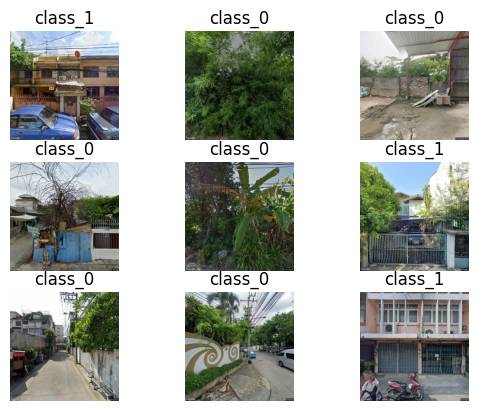

In [27]:
def format_label(label):
    return f"class_{int(label)}"

for i, (image, label) in enumerate(ds_train.unbatch().take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(tf.cast(image, tf.float32) / 255.0)
    plt.title(format_label(label))
    plt.axis("off")

In [28]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB4

data_augmentation = keras.Sequential([
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="aug")

def build_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)

    backbone = EfficientNetB4(
        include_top=False,
        input_tensor=x,
        weights="imagenet"
    )
    backbone.trainable = False

    x = layers.GlobalAveragePooling2D()(backbone.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [29]:
import matplotlib.pyplot as plt

def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()

In [30]:
oof_pred = np.zeros(len(df), dtype=np.float32)
test_pred = np.zeros(len(test_df), dtype=np.float32)
fold_scores = []

ds_test = make_dataset(test_df, training=False, has_label=False)

for fold, (train_idx, val_idx) in enumerate(folds):
    print("=" * 50)
    print(f"FOLD {fold}")
    print("=" * 50)

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    ds_train = make_dataset(train_df, training=True, has_label=True)
    ds_val = make_dataset(val_df, training=False, has_label=True)

    model = build_model()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True
        )
    ]

    hist = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=15,
        callbacks=callbacks,
        verbose=1
    )

    for layer in model.layers:
        layer.trainable = True

    for layer in model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(3e-6),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    callbacks_ft = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7
        )
    ]

    hist_ft = model.fit(
        ds_train,
        validation_data=ds_val,
        epochs=10,
        callbacks=callbacks_ft,
        verbose=1
    )

    val_probs = model.predict(ds_val, verbose=0).ravel()
    val_pred = (val_probs >= 0.5).astype(int)
    val_true = val_df["label"].values

    fold_acc = accuracy_score(val_true, val_pred)
    fold_scores.append(fold_acc)
    oof_pred[val_idx] = val_probs

    fold_test_pred = model.predict(ds_test, verbose=0).ravel()
    test_pred += fold_test_pred / len(folds)

    print(f"Fold {fold} Accuracy: {fold_acc:.4f}")

print("\nFold scores:", [round(x, 4) for x in fold_scores])
print(f"Mean CV Accuracy: {np.mean(fold_scores):.4f}")

FOLD 0
Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 40s 121ms/step - accuracy: 0.8402 - loss: 0.3802 - val_accuracy: 0.9364 - val_loss: 0.2707
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.8861 - loss: 0.2764 - val_accuracy: 0.9416 - val_loss: 0.1907
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.8967 - loss: 0.2574 - val_accuracy: 0.9364 - val_loss: 0.1633
Epoch 4/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.8891 - loss: 0.2586 - val_accuracy: 0.9485 - val_loss: 0.1582
Epoch 5/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.8946 - loss: 0.2541 - val_accuracy: 0.9519 - val_loss: 0.1591
Epoch 6/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.8988 - loss: 0.2422 - val_accuracy: 0.9502 - val_loss: 0.1508
Epoch 7/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.9161 - loss: 0.2121 - val_accuracy: 0.9553 - val_loss: 0.1526
Epoch 8/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.9127 - loss: 0

In [31]:
best_thr = 0.5
best_acc = 0.0

for thr in np.arange(0.30, 0.71, 0.01):
    pred_label = (oof_pred >= thr).astype(int)
    acc = accuracy_score(df["label"].values, pred_label)
    if acc > best_acc:
        best_acc = acc
        best_thr = thr

print(f"Best threshold: {best_thr:.2f}")
print(f"Best OOF Accuracy: {best_acc:.4f}")

Best threshold: 0.50
Best OOF Accuracy: 0.9421


In [32]:
test_df["answer"] = (test_pred >= best_thr).astype(int)
test_df["id"] = test_df["image_name"].str.replace(".jpg", "", regex=False)

submission = test_df[["id", "answer"]]
submission.to_csv("submission.csv", index=False)

print(submission.head())
print(submission.shape)

         id  answer
0  00162f19       0
1  004c4789       0
2  0059b42f       1
3  005f930c       0
4  009095e8       1
(1550, 2)
